In [1]:
from pathlib import Path
import os

PROJECT_NAME = "MALDIAlign"

cwd = Path().resolve()

# Walk upwards until we find the project folder
target = None
for parent in [cwd] + list(cwd.parents):
    if parent.name == PROJECT_NAME:
        target = parent
        break

# If the project folder is found and we are not already there, then change cwd
if target is not None and target != cwd:
    os.chdir(target)

print("Working directory:", os.getcwd())

Working directory: /export/usuarios01/agnavarr/MALDIAlign


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from utils.load_config import load_config
from utils.load_data import load_pkl

from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import balanced_accuracy_score
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier

## Data loading

In [3]:
cfg = load_config()
driams_pkl = cfg["data"]["DRIAMS_REDUCED_PKL"]

In [4]:
driams = load_pkl(driams_pkl)

In [5]:
data, label, meta = driams["data"], driams["label"], driams["meta"]

In [6]:
meta = pd.DataFrame.from_records(list(meta))

In [7]:
type(data), type(label), type(meta)

(numpy.ndarray, numpy.ndarray, pandas.core.frame.DataFrame)

In [8]:
np.unique(label)

array(['Enterobacter_cloacae_complex', 'Enterococcus_Faecium',
       'Escherichia_Coli', 'Klebsiella_Pneumoniae',
       'Pseudomonas_Aeruginosa', 'Staphylococcus_Aureus'], dtype='<U28')

In [9]:
species, counts = np.unique(label, return_counts=True)
for sp, n in zip(species, counts):
    print(f"{sp}: {n}")

Enterobacter_cloacae_complex: 3351
Enterococcus_Faecium: 2136
Escherichia_Coli: 11160
Klebsiella_Pneumoniae: 6791
Pseudomonas_Aeruginosa: 5824
Staphylococcus_Aureus: 10519


In [10]:
meta["hospital"].value_counts()

hospital
DRIAMS_A    27810
DRIAMS_D     7308
DRIAMS_C     2677
DRIAMS_B     1986
Name: count, dtype: int64

In [11]:
meta

,hospital,year,genus,species,study
0,DRIAMS_B,2018,Klebsiella,Pneumoniae,23a9e0ba-d4b2-40eb-808c-37270a5117dc.txt
1,DRIAMS_B,2018,Klebsiella,Pneumoniae,36437826-52fa-4daf-8f2b-4133f4307156.txt
2,DRIAMS_B,2018,Klebsiella,Pneumoniae,da983ae0-e887-4771-bdb1-9a8d564eb017.txt
3,DRIAMS_B,2018,Klebsiella,Pneumoniae,5e8f4603-1399-4ad5-a618-7e8bf2fc4207.txt
4,DRIAMS_B,2018,Klebsiella,Pneumoniae,ce63ff87-717d-4eac-8dca-590ffa840867.txt
...,...,...,...,...,...
39776,DRIAMS_A,2017,Enterobacter,Ludwigii,12a9f8dc-2ea4-4e61-9cb3-8a318e207b72_MALDI1.txt
39777,DRIAMS_C,2018,Enterobacter,Ludwigii,28082703960_A6.txt
39778,DRIAMS_C,2018,Enterobacter,Ludwigii,28020109560_F1.txt
39779,DRIAMS_C,2018,Enterobacter,Ludwigii,28030306620_F3.txt


In [12]:
# Filter the data by hospital
filtered_data = {}
for hosp in meta["hospital"].unique():
    idx = np.where(meta["hospital"].values == hosp)[0]
    filtered_data[hosp] = {
        "data": data[idx],
        "label": label[idx],
        "meta": meta.iloc[idx]
    }

In [13]:
species, counts = np.unique(filtered_data["DRIAMS_A"]["label"], return_counts=True)
for sp, n in zip(species, counts):
    print(f"{sp}: {n}")

Enterobacter_cloacae_complex: 2573
Enterococcus_Faecium: 1800
Escherichia_Coli: 7381
Klebsiella_Pneumoniae: 4083
Pseudomonas_Aeruginosa: 4908
Staphylococcus_Aureus: 7065


In [14]:
# Declare the datasets
dataA, labelA, metaA = filtered_data["DRIAMS_A"]["data"], filtered_data["DRIAMS_A"]["label"], filtered_data["DRIAMS_A"]["meta"]
dataB, labelB, metaB = filtered_data["DRIAMS_B"]["data"], filtered_data["DRIAMS_B"]["label"], filtered_data["DRIAMS_B"]["meta"]
dataC, labelC, metaC = filtered_data["DRIAMS_C"]["data"], filtered_data["DRIAMS_C"]["label"], filtered_data["DRIAMS_C"]["meta"]
dataD, labelD, metaD = filtered_data["DRIAMS_D"]["data"], filtered_data["DRIAMS_D"]["label"], filtered_data["DRIAMS_D"]["meta"]

## Models

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(dataA, labelA, test_size=0.4, stratify=labelA)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp)

In [16]:
# Scale the data
scaler = StandardScaler()
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

### Logistic Regression

In [52]:
# Apply PCA to reduce the dimensionality (there are 6000 features)
my_pca = PCA().fit(X_train_scaled)

In [53]:
# explained_variance_ returns the amount of variance explained by each of the selected components
# explained_variance_ratio_ returnd the percentage of variance explained by each of the selected components
cumulative_explained_var = np.cumsum(my_pca.explained_variance_)
cumulative_explained_var_ratio = np.cumsum(my_pca.explained_variance_ratio_)

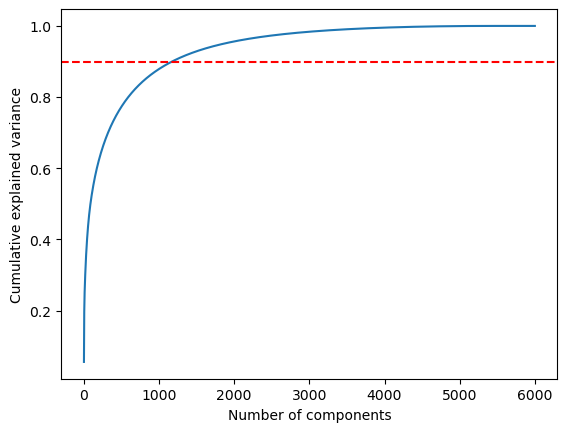

In [54]:
plt.plot(np.arange(1, len(cumulative_explained_var_ratio)+1), cumulative_explained_var_ratio)
plt.axhline(0.9, color='r', linestyle='--')
plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance")
plt.show()

In [55]:
n_components = np.argmax(cumulative_explained_var_ratio >= 0.85) + 1
print(f"Number of components explaining 85% variance: {n_components}")

Number of components explaining 85% variance: 816


In [56]:
pca = PCA(n_components=816)
pca.fit(X_train_scaled)

X_train_pca = pca.transform(X_train_scaled)
X_val_pca   = pca.transform(X_val_scaled)
X_test_pca  = pca.transform(X_test_scaled)

In [57]:
# Define the hyperparameters to train on
lr_C = np.logspace(-3, 3, 10)

train_scores = []
val_scores = []

for C in lr_C:
    # Define and train the model
    model = LogisticRegression(C=C, class_weight='balanced', max_iter=1000)
    model.fit(X_train_pca, y_train)

    # Predict and evaluate
    y_pred_train = model.predict(X_train_pca)
    y_pred_val = model.predict(X_val_pca)

    acc_train = balanced_accuracy_score(y_train, y_pred_train)
    acc_val = balanced_accuracy_score(y_val, y_pred_val)

    train_scores.append(acc_train)
    val_scores.append(acc_val)

    print(f"C={C:.3f} → Train: {acc_train:.3f}, Val: {acc_val:.3f}")

C=0.001 → Train: 1.000, Val: 0.998
C=0.005 → Train: 1.000, Val: 0.998
C=0.022 → Train: 1.000, Val: 0.998
C=0.100 → Train: 1.000, Val: 0.997
C=0.464 → Train: 1.000, Val: 0.997
C=2.154 → Train: 1.000, Val: 0.997
C=10.000 → Train: 1.000, Val: 0.997
C=46.416 → Train: 1.000, Val: 0.997
C=215.443 → Train: 1.000, Val: 0.997
C=1000.000 → Train: 1.000, Val: 0.997


In [58]:
#  Select the best model
best_idx = np.argmax(val_scores)
best_C = lr_C[best_idx]
print(f"\nBest C = {best_C:.3f} (Val balanced accuracy = {val_scores[best_idx]:.3f})")


Best C = 0.005 (Val balanced accuracy = 0.998)


In [59]:
# Evaluate in test
best_model = LogisticRegression(C=best_C, class_weight='balanced', max_iter=1000)
best_model.fit(X_train_scaled, y_train)
y_pred_test = best_model.predict(X_test_scaled)
test_acc = balanced_accuracy_score(y_test, y_pred_test)
print(test_acc)

0.9985058098274471


In [60]:
# Store results
results_lr = pd.DataFrame({
    "C": lr_C,
    "Train_Acc": train_scores,
    "Val_Acc": val_scores
})
results_lr

,C,Train_Acc,Val_Acc
0,0.001000,0.999678,0.998064
1,0.004642,0.999868,0.998268
2,0.021544,0.999868,0.997781
3,0.100000,0.999868,0.997458
4,0.464159,0.999868,0.997086
5,2.154435,0.999868,0.996827
6,10.000000,0.999868,0.996827
7,46.415888,0.999868,0.996827
8,215.443469,0.999868,0.996827
9,1000.000000,0.999868,0.996827


In [61]:
results_lr.to_csv("results_lr.csv", index=False)

### RF

### SVM-Linear

In [ ]:
from sklearn.svm import SVC
model = SVC(kernel='linear', class_weight='balanced', C=0.001).fit(X_train_scaled, y_train)

In [ ]:
# Evaluate
y_pred_test = model.predict(X_test_scaled)
acc_test = balanced_accuracy_score(y_test, y_pred_test)
print("Balanced accuracy (test):", acc_test)

### SVM-RBF

In [ ]:
model = SVC(kernel='rbf', class_weight='balanced', C=10, gamma=1.6666666666666668e-07).fit(X_train_scaled, y_train)
y_pred_test = model.predict(X_test_scaled)
acc_test = balanced_accuracy_score(y_test, y_pred_test)
print("Balanced accuracy (test):", acc_test)